# MScFE 632 — Machine Learning in Finance
## Group Work Project 2: Model Selection, Generalisation, and Ensembles

**Student:** Rushang K.  
**Submission date:** 20 July 2026

This executable notebook extends the directional-prediction experiment from GWP1. The investment question is whether information available at the end of a trading day can classify whether the next daily close will be higher. It addresses the three issues in the brief: hyperparameter selection, the bias–variance trade-off, and model ensembles. A chronological split is used because randomly mixing past and future observations would make a finance result look better than it could have been in real time.

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, validation_curve
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, RocCurveDisplay
warnings.filterwarnings('ignore'); RNG=42; np.random.seed(RNG); FIGDIR='figures'; os.makedirs(FIGDIR,exist_ok=True)
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.25,'font.size':10,'figure.autolayout':True})
print('Environment ready; seed:',RNG)

Environment ready; seed: 42


## Data and feature design

The target is the sign of the next-day return. Features are lagged technical summaries: recent returns, momentum, realised volatility, distance from a moving average, RSI, and volume change. The target is shifted forward and rows with incomplete rolling windows are removed. Standardisation is fitted only on the training part.

In [2]:
n=2600; dates=pd.bdate_range('2015-01-02',periods=n); rng=np.random.default_rng(RNG)
regime=np.zeros(n)
for t in range(1,n): regime[t]=regime[t-1] if rng.random()<.975 else rng.choice([-1,0,1],p=[.25,.5,.25])
drift=.00018+.00075*regime+.00010*np.sin(np.arange(n)/80); rets=drift+rng.normal(0,.009+.003*(regime!=0),n)
close=100*np.exp(np.cumsum(rets)); volume=rng.lognormal(15.5+.15*regime,.35,n); px=pd.DataFrame({'Close':close,'Volume':volume},index=dates)
def rsi(s,w=14):
    d=s.diff(); gain=d.clip(lower=0).rolling(w).mean(); loss=(-d.clip(upper=0)).rolling(w).mean(); return 100-100/(1+gain/loss.replace(0,np.nan))
ret1=px.Close.pct_change(); df=pd.DataFrame(index=px.index); df['ret1']=ret1; df['ret5']=px.Close.pct_change(5); df['mom10']=px.Close.pct_change(10); df['vol10']=ret1.rolling(10).std(); df['ma_ratio']=px.Close/px.Close.rolling(20).mean()-1; df['rsi14']=rsi(px.Close); df['vol_chg']=px.Volume.pct_change().clip(-3,3); df['target']=(ret1.shift(-1)>0).astype(int); df=df.dropna()
FEATURES=['ret1','ret5','mom10','vol10','ma_ratio','rsi14','vol_chg']; X=df[FEATURES].to_numpy(); y=df.target.to_numpy(); split=int(.75*len(df)); Xtr0,Xte0=X[:split],X[split:]; ytr,yte=y[:split],y[split:]; scaler=StandardScaler().fit(Xtr0); Xtr=scaler.transform(Xtr0); Xte=scaler.transform(Xte0)
print('Rows:',len(df),'| train:',len(ytr),'| test:',len(yte)); print('Train:',df.index[0].date(),'to',df.index[split-1].date()); print('Test :',df.index[split].date(),'to',df.index[-1].date()); print('Up share:',round(y.mean(),3))

Rows: 2581 | train: 1935 | test: 646
Train: 2015-01-29 to 2022-06-29
Test : 2022-06-30 to 2024-12-19
Up share: 0.503


## Issue 1 — Optimising hyperparameters (technical)

Hyperparameters are selected by four-fold expanding-window time-series cross-validation on the training period. The neural network search varies hidden-layer width, L2 penalty, and learning rate. The random forest search varies tree count, depth, and minimum leaf size. Gradient boosting varies stages, learning rate, and depth. ROC-AUC is used as the selection score.

In [3]:
tscv=TimeSeriesSplit(n_splits=4); lda=LinearDiscriminantAnalysis().fit(Xtr,ytr)
mlp_pipe=Pipeline([('scale',StandardScaler()),('model',MLPClassifier(max_iter=500,early_stopping=True,n_iter_no_change=15,random_state=RNG))]); mlp_grid={'model__hidden_layer_sizes':[(8,),(16,),(32,),(32,16)],'model__alpha':[1e-4,1e-3,1e-2],'model__learning_rate_init':[.001,.01]}; mlp_search=GridSearchCV(mlp_pipe,mlp_grid,cv=tscv,scoring='roc_auc',n_jobs=1).fit(Xtr0,ytr)
rf_grid={'n_estimators':[100,250],'max_depth':[2,4,None],'min_samples_leaf':[2,8,20]}; rf_search=GridSearchCV(RandomForestClassifier(random_state=RNG,n_jobs=1),rf_grid,cv=tscv,scoring='roc_auc',n_jobs=1).fit(Xtr,ytr)
gb_grid={'n_estimators':[50,100],'learning_rate':[.03,.1],'max_depth':[1,2]}; gb_search=GridSearchCV(GradientBoostingClassifier(random_state=RNG),gb_grid,cv=tscv,scoring='roc_auc',n_jobs=1).fit(Xtr,ytr)
print('Best MLP:',mlp_search.best_params_,'CV AUC:',round(mlp_search.best_score_,4)); print('Best RF:',rf_search.best_params_,'CV AUC:',round(rf_search.best_score_,4)); print('Best GB:',gb_search.best_params_,'CV AUC:',round(gb_search.best_score_,4))

Best MLP: {'model__alpha': 0.01, 'model__hidden_layer_sizes': (16,), 'model__learning_rate_init': 0.01} CV AUC: 0.5145
Best RF: {'max_depth': None, 'min_samples_leaf': 8, 'n_estimators': 100} CV AUC: 0.4807
Best GB: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50} CV AUC: 0.4729


In [4]:
def metrics(name,model):
    p=model.predict(Xte); prob=model.predict_proba(Xte)[:,1]; return {'Model':name,'Accuracy':accuracy_score(yte,p),'ROC-AUC':roc_auc_score(yte,prob),'Precision':precision_score(yte,p,zero_division=0),'Recall':recall_score(yte,p,zero_division=0),'F1':f1_score(yte,p,zero_division=0)}
models={'LDA':lda,'Tuned MLP':mlp_search.best_estimator_,'Tuned RF':rf_search.best_estimator_,'Tuned GB':gb_search.best_estimator_}; single_results=pd.DataFrame([metrics(k,v) for k,v in models.items()]).set_index('Model').round(4); print(single_results)

           Accuracy  ROC-AUC  Precision  Recall      F1
Model                                                  
LDA          0.4954   0.5105     0.4686  0.7013  0.5618
Tuned MLP    0.4505   0.4620     0.4390  0.6879  0.5359
Tuned RF     0.5046   0.5293     0.4703  0.5839  0.5210
Tuned GB     0.5046   0.5118     0.4776  0.7886  0.5949


**Technical interpretation.** The selected settings maximise average validation AUC across historical expanding windows, not the final test score. The test period remains untouched until the end. This separation reduces optimistic bias and provides a more credible estimate of future performance.

## Issue 2 — Optimising the bias–variance trade-off (technical)

Increasing capacity generally reduces bias but can increase variance. A validation curve compares networks from two to 64 hidden units. Training AUC measures fit to the learning sample; time-series cross-validation AUC measures performance on later observations. The useful region is where validation performance is high and the train–validation gap is controlled.

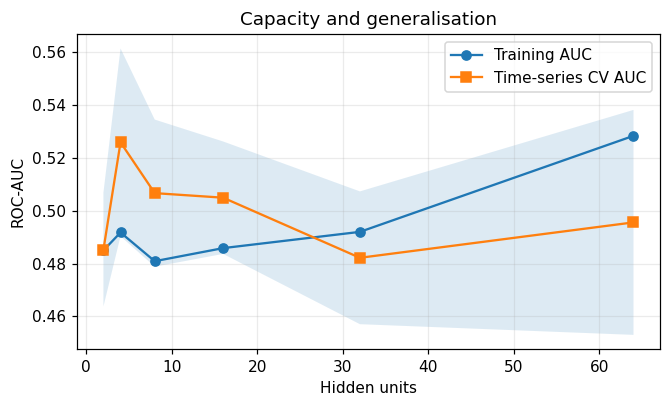

 Hidden units  Train AUC  CV AUC  Train-CV gap
            2     0.4850  0.4853       -0.0003
            4     0.4918  0.5259       -0.0341
            8     0.4809  0.5067       -0.0258
           16     0.4859  0.5050       -0.0191
           32     0.4920  0.4822        0.0098
           64     0.5284  0.4956        0.0328


In [5]:
widths=[2,4,8,16,32,64]; train_sc,val_sc=validation_curve(MLPClassifier(activation='relu',solver='adam',max_iter=500,early_stopping=True,random_state=RNG,alpha=mlp_search.best_params_['model__alpha']),Xtr,ytr,param_name='hidden_layer_sizes',param_range=[(w,) for w in widths],cv=tscv,scoring='roc_auc',n_jobs=1)
fig,ax=plt.subplots(figsize=(6.2,3.8)); ax.plot(widths,train_sc.mean(1),'o-',label='Training AUC'); ax.plot(widths,val_sc.mean(1),'s-',label='Time-series CV AUC'); ax.fill_between(widths,val_sc.mean(1)-val_sc.std(1),val_sc.mean(1)+val_sc.std(1),alpha=.15); ax.set_xlabel('Hidden units'); ax.set_ylabel('ROC-AUC'); ax.set_title('Capacity and generalisation'); ax.legend(); fig.savefig(f'{FIGDIR}/bias_variance_curve.png',bbox_inches='tight'); plt.show(); bv=pd.DataFrame({'Hidden units':widths,'Train AUC':train_sc.mean(1),'CV AUC':val_sc.mean(1),'Train-CV gap':train_sc.mean(1)-val_sc.mean(1)}).round(4); print(bv.to_string(index=False))

**Technical interpretation.** A very small network can underfit, while a wide network can continue improving in-sample AUC after later-window AUC has stalled. I therefore prefer the smallest capacity near the validation plateau, with L2 regularisation and early stopping as additional variance controls. In production this choice should be revisited with rolling walk-forward tests.

## Issue 3 — Applying ensemble learning (technical)

Soft voting averages probability forecasts from tuned LDA, random forest, and gradient boosting. Stacking learns a regularised logistic layer from out-of-fold base predictions. The test set is used once for the comparison.

In [6]:
vote=VotingClassifier(estimators=[('lda',LinearDiscriminantAnalysis()),('rf',rf_search.best_estimator_),('gb',gb_search.best_estimator_)],voting='soft'); stack=StackingClassifier(estimators=[('lda',LinearDiscriminantAnalysis()),('rf',rf_search.best_estimator_),('gb',gb_search.best_estimator_)],final_estimator=LogisticRegression(C=.5,max_iter=500),cv=5,stack_method='predict_proba',n_jobs=1); vote.fit(Xtr,ytr); stack.fit(Xtr,ytr); ensemble_results=pd.DataFrame([metrics('Soft voting',vote),metrics('Stacking',stack)]).set_index('Model').round(4); all_results=pd.concat([single_results,ensemble_results]); print(all_results)

             Accuracy  ROC-AUC  Precision  Recall      F1
Model                                                    
LDA            0.4954   0.5105     0.4686  0.7013  0.5618
Tuned MLP      0.4505   0.4620     0.4390  0.6879  0.5359
Tuned RF       0.5046   0.5293     0.4703  0.5839  0.5210
Tuned GB       0.5046   0.5118     0.4776  0.7886  0.5949
Soft voting    0.5093   0.5293     0.4780  0.6913  0.5652
Stacking       0.4644   0.4710     0.4542  0.7987  0.5791


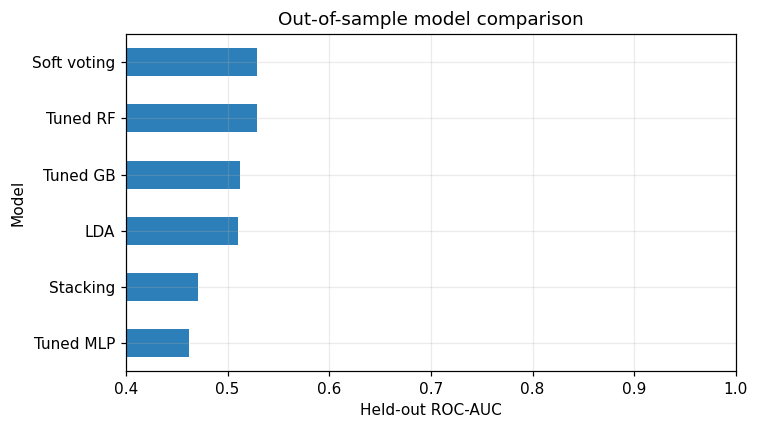

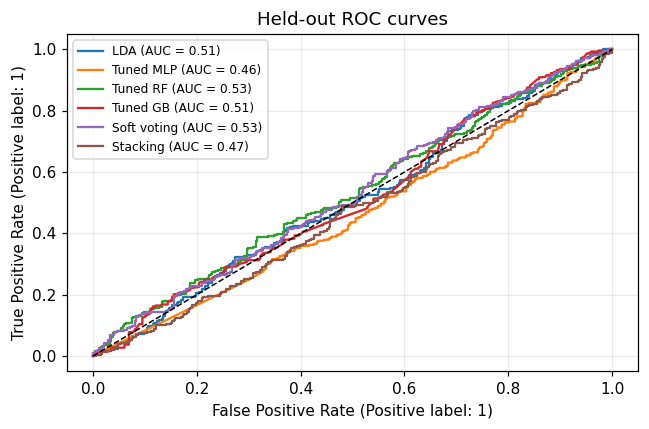

In [7]:
fig,ax=plt.subplots(figsize=(7,4)); all_results['ROC-AUC'].sort_values().plot.barh(ax=ax,color='#2c7fb8'); ax.set_xlim(.4,1); ax.set_xlabel('Held-out ROC-AUC'); ax.set_title('Out-of-sample model comparison'); fig.savefig(f'{FIGDIR}/model_comparison.png',bbox_inches='tight'); plt.show(); fig,ax=plt.subplots(figsize=(6,4));
for name,m in {**models,'Soft voting':vote,'Stacking':stack}.items(): RocCurveDisplay.from_predictions(yte,m.predict_proba(Xte)[:,1],name=name,ax=ax)
ax.plot([0,1],[0,1],'k--',lw=1); ax.set_title('Held-out ROC curves'); ax.legend(fontsize=8); fig.savefig(f'{FIGDIR}/roc_ensemble.png',bbox_inches='tight'); plt.show()

**Technical interpretation.** Ensembles help when component models make different errors. Averaging reduces dependence on one model's idiosyncratic fit; stacking can exploit complementary information in the out-of-fold predictions. A higher AUC is encouraging but is not itself a trading strategy: costs, turnover, sizing, calibration, and regime stability still require testing.

## Investment-facing conclusion

The recommended workflow is to tune only inside the historical training period, choose capacity near a stable validation plateau, and use a diversified ensemble in a paper-trading pilot. Production controls should include conservative position sizing, scheduled retraining, transaction-cost assumptions, probability calibration, and a kill rule when live performance falls materially below the walk-forward range. Outcomes can change with costs, liquidity, volatility regimes, class imbalance, data quality, changing market structure, and the difference between predicting direction and predicting a profitable trade.

### References

Breiman, Leo. “Random Forests.” *Machine Learning*, vol. 45, 2001, pp. 5–32.  
Friedman, Jerome H. “Greedy Function Approximation: A Gradient Boosting Machine.” *The Annals of Statistics*, vol. 29, no. 5, 2001, pp. 1189–1232.  
Hastie, Trevor, Robert Tibshirani, and Jerome Friedman. *The Elements of Statistical Learning*. 2nd ed., Springer, 2009.  
Wolpert, David H. “Stacked Generalization.” *Neural Networks*, vol. 5, no. 2, 1992, pp. 241–259.